# EDA — IBM Telco Customer Churn
This notebook loads the cleaned Telco dataset, shows a quick overview, and provides starter visualizations for exploratory analysis. Run cells in order.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Navigate up from notebooks/ to project root
ROOT = os.path.dirname(os.getcwd())
CSV = os.path.join(ROOT, 'data', 'processed', 'telco_cleaned.csv')

print('Data path:', CSV)
df = pd.read_csv(CSV)
df.head()

Data path: c:\Users\prajy\OneDrive\Desktop\work\apex_planet_dataAnalysis\apexplanet-data-analytics\data\processed\telco_cleaned.csv


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Churn,ChurnBinary
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,Yes,1
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,Yes,1
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Electronic check,99.65,820.5,Yes,1,86,5372,Moved,Yes,1
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,Yes,1
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices,Yes,1


In [2]:
# Quick overview - lightweight (faster)
df.info()
print('\nNumeric Summary:')
df.describe()
print('\nCategorical Columns:')
print(df.select_dtypes('object').nunique().sort_values())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [4]:
# Example plot: churn by contract (don't show, just close)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract')
plt.close()

In [5]:
# Save all visuals to reports/ (faster - save then close, no inline rendering)
REPORTS = os.path.join(ROOT, 'reports')
os.makedirs(REPORTS, exist_ok=True)

# Churn by contract
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract')
plt.savefig(os.path.join(REPORTS, 'churn_by_contract.png'), bbox_inches='tight')
plt.close()

# Monthly Charges distribution (no KDE for speed)
plt.figure(figsize=(8, 4))
sns.histplot(df['Monthly Charges'], kde=False, bins=30)
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.savefig(os.path.join(REPORTS, 'monthlycharges_dist.png'), bbox_inches='tight')
plt.close()

# Tenure months histogram
plt.figure(figsize=(8, 4))
sns.histplot(df['Tenure Months'], bins=30)
plt.title('Tenure Months Distribution')
plt.xlabel('Tenure Months')
plt.savefig(os.path.join(REPORTS, 'tenure_hist.png'), bbox_inches='tight')
plt.close()

# Churn counts
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.savefig(os.path.join(REPORTS, 'churn_counts.png'), bbox_inches='tight')
plt.close()

# Correlation heatmap for numeric columns only
num_cols = df.select_dtypes(include=['number']).columns.tolist()
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'correlation_heatmap.png'), bbox_inches='tight')
plt.close()

print('✓ All 5 visuals saved to reports/')

✓ All 5 visuals saved to reports/


# EDA — IBM Telco Customer Churn
This notebook loads the cleaned Telco dataset, shows a quick overview, and provides starter visualizations for exploratory analysis. Run cells in order.

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Navigate up from notebooks/ to project root
ROOT = os.path.dirname(os.getcwd())
CSV = os.path.join(ROOT, 'data', 'processed', 'telco_cleaned.csv')

print('Data path:', CSV)
df = pd.read_csv(CSV)
df.head()

Data path: c:\Users\prajy\OneDrive\Desktop\work\apex_planet_dataAnalysis\apexplanet-data-analytics\data\processed\telco_cleaned.csv


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Churn,ChurnBinary
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,Yes,1
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,Yes,1
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Electronic check,99.65,820.5,Yes,1,86,5372,Moved,Yes,1
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,Yes,1
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices,Yes,1


In [7]:
# Quick overview - lightweight (faster)
df.info()
print('\nNumeric Summary:')
df.describe()
print('\nCategorical Columns:')
print(df.select_dtypes('object').nunique().sort_values())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [8]:
# Example plot: churn by contract (don't show, just close)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract')
plt.close()

In [9]:
# Save all visuals to reports/ (faster - save then close, no inline rendering)
REPORTS = os.path.join(ROOT, 'reports')
os.makedirs(REPORTS, exist_ok=True)

# Churn by contract
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract')
plt.savefig(os.path.join(REPORTS, 'churn_by_contract.png'), bbox_inches='tight')
plt.close()

# Monthly Charges distribution (no KDE for speed)
plt.figure(figsize=(8, 4))
sns.histplot(df['Monthly Charges'], kde=False, bins=30)
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.savefig(os.path.join(REPORTS, 'monthlycharges_dist.png'), bbox_inches='tight')
plt.close()

# Tenure months histogram
plt.figure(figsize=(8, 4))
sns.histplot(df['Tenure Months'], bins=30)
plt.title('Tenure Months Distribution')
plt.xlabel('Tenure Months')
plt.savefig(os.path.join(REPORTS, 'tenure_hist.png'), bbox_inches='tight')
plt.close()

# Churn counts
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.savefig(os.path.join(REPORTS, 'churn_counts.png'), bbox_inches='tight')
plt.close()

# Correlation heatmap for numeric columns only
num_cols = df.select_dtypes(include=['number']).columns.tolist()
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'correlation_heatmap.png'), bbox_inches='tight')
plt.close()

print('✓ All 5 visuals saved to reports/')

✓ All 5 visuals saved to reports/


# EDA — IBM Telco Customer Churn
This notebook loads the cleaned Telco dataset, shows a quick overview, and provides starter visualizations for exploratory analysis. Run cells in order.

In [1]:
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Resolve project root whether the notebook was launched from /notebooks or project root.
cwd = os.getcwd()
ROOT = cwd if os.path.basename(cwd) == 'apexplanet-data-analytics' else os.path.dirname(cwd)

PARQUET = os.path.join(ROOT, 'data', 'processed', 'telco_cleaned.parquet')
PICKLE = os.path.join(ROOT, 'data', 'processed', 'telco_cleaned.pkl')
CSV = os.path.join(ROOT, 'data', 'processed', 'telco_cleaned.csv')

# Prefer faster formats first.
if os.path.exists(PARQUET):
    DATA = PARQUET
    df = pd.read_parquet(DATA)
elif os.path.exists(PICKLE):
    DATA = PICKLE
    df = pd.read_pickle(DATA)
else:
    DATA = CSV
    df = pd.read_csv(DATA)

print('Data path:', DATA)
df.head()

Data path: c:\Users\prajy\OneDrive\Desktop\work\apex_planet_dataAnalysis\apexplanet-data-analytics\data\processed\telco_cleaned.parquet


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Churn,ChurnBinary
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,Yes,1
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,Yes,1
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Electronic check,99.65,820.5,Yes,1,86,5372,Moved,Yes,1
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,Yes,1
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices,Yes,1


In [2]:
# Quick overview
df.info()
print('\nNumeric Summary:')
df.describe()
print('\nCategorical Columns:')
print(df.select_dtypes('object').nunique().sort_values())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

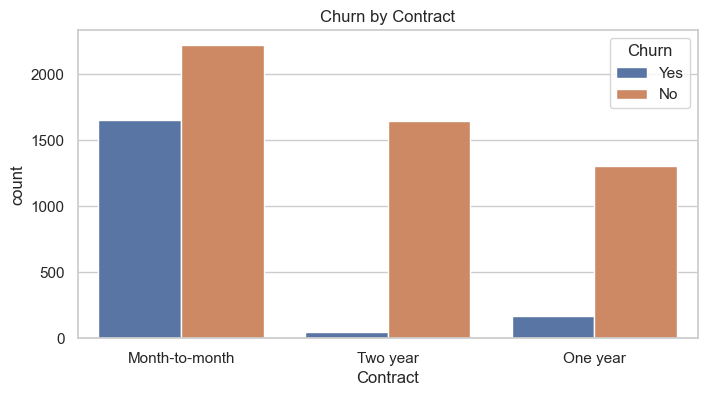

In [3]:
# Example plot: churn by contract
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract')
plt.close()

In [10]:
# Save additional visuals to reports/
import os
REPORTS = os.path.join(ROOT, 'reports')
os.makedirs(REPORTS, exist_ok=True)

# churn by contract (save)
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract')
plt.savefig(os.path.join(REPORTS, 'churn_by_contract.png'), bbox_inches='tight')
plt.close()

# Monthly Charges distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Monthly Charges'], kde=False, bins=30)
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.savefig(os.path.join(REPORTS, 'monthlycharges_dist.png'), bbox_inches='tight')
plt.close()

# Tenure months histogram
plt.figure(figsize=(8,4))
sns.histplot(df['Tenure Months'], bins=30)
plt.title('Tenure Months Distribution')
plt.xlabel('Tenure Months')
plt.savefig(os.path.join(REPORTS, 'tenure_hist.png'), bbox_inches='tight')
plt.close()

# Correlation heatmap for numeric columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()
plt.figure(figsize=(10,8))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (numeric)')
plt.savefig(os.path.join(REPORTS, 'correlation_heatmap.png'), bbox_inches='tight')
plt.close()
print('✓ All visuals saved to reports/')


✓ All visuals saved to reports/
